In [251]:
# =========================================================
# 0. Setup
# =========================================================
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ---------------------------------------------------------
# Global config
# ---------------------------------------------------------
LOG_DIR = Path("/home/jung/jung/LIBERO/openvla/experiments/logs/token_dists_libero_spatial_openvla")

BASE_METRICS = [
    "confidence",
    "entropy",
    "margin",
    "vr",
    "top3_mass",
    "top5_mass",
    "exp_dist",
]

SCORE_WINDOWS = [1, 2, 3, 4, 5, 6, 7]

# SCORE_THRESHOLDS = {
#     "confidence": [0.03, 0.04, 0.05, 0.06],
#     "entropy":    [0.12, 0.14, 0.16, 0.18],
#     "margin":     [0.06, 0.075, 0.09, 0.105],
#     "vr":         [0.03, 0.04, 0.05, 0.06],
#     "top3_mass":  [0.02, 0.03, 0.04, 0.05],
#     "top5_mass":  [0.02, 0.03, 0.04, 0.05],
#     "exp_dist":   [0.10, 0.15, 0.20, 0.25],
# }
SCORE_THRESHOLDS = {
    "confidence": [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
    "entropy":    [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
    "margin":     [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
    "vr":         [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
    "top3_mass":  [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
    "top5_mass":  [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
    "exp_dist":   [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0],
}

MIN_GAP = 3

MIN_SUCCESS_PER_TASK = 2
MIN_FAIL_PER_TASK = 2

FAIL_HIGH_EVENT_THRESHOLD = 20

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

In [252]:
# =========================================================
# 1. Data structures
# =========================================================
@dataclass
class RolloutRecord:
    task_name: str
    task_id: Any
    trial_id: Any
    rollout_id: str
    success: int
    pt_name: str
    step_ids: np.ndarray
    traj_len: int
    logits: torch.Tensor


@dataclass
class TaskHorizon:
    task_name: str
    n_success: int
    n_fail: int
    success_len_mean: float
    success_len_median: float
    all_len_mean: float
    all_len_median: float
    cutoff_len: int
    is_valid_task: bool

In [253]:
# =========================================================
# 2. Load rollouts
# =========================================================
def load_rollouts(log_dir: Path) -> List[RolloutRecord]:
    pt_files = sorted(log_dir.glob("*.pt"))
    records: List[RolloutRecord] = []

    for pt_path in pt_files:
        raw = torch.load(pt_path, map_location="cpu")

        if raw["logits"].numel() == 0:
            continue

        rollout_id = f"{raw['task_id']}_{raw['trial_id']}"

        records.append(
            RolloutRecord(
                task_name=raw["task_name"],
                task_id=raw["task_id"],
                trial_id=raw["trial_id"],
                rollout_id=rollout_id,
                success=int(raw["success"]),
                pt_name=pt_path.name,
                step_ids=np.asarray(raw["step_ids"]),
                traj_len=int(len(raw["step_ids"])),
                logits=raw["logits"].float(),
            )
        )

    return records


def build_rollout_df(rollouts: List[RolloutRecord]) -> pd.DataFrame:
    rows = []
    for r in rollouts:
        rows.append({
            "task_name": r.task_name,
            "task_id": r.task_id,
            "trial_id": r.trial_id,
            "rollout_id": r.rollout_id,
            "success": r.success,
            "pt_name": r.pt_name,
            "traj_len": r.traj_len,
        })
    return pd.DataFrame(rows)


rollouts = load_rollouts(LOG_DIR)
rollout_df = build_rollout_df(rollouts)

print(f"# usable rollouts: {len(rollouts)}")
display(rollout_df.head())

# usable rollouts: 100


,task_name,task_id,trial_id,rollout_id,success,pt_name,traj_len
0,pick_up_the_black_bowl_between_the_plate_and_t...,0,0,0_0,1,task000_trial000_success1.pt,87
1,pick_up_the_black_bowl_between_the_plate_and_t...,0,1,0_1,0,task000_trial001_success0.pt,220
2,pick_up_the_black_bowl_between_the_plate_and_t...,0,2,0_2,1,task000_trial002_success1.pt,87
3,pick_up_the_black_bowl_between_the_plate_and_t...,0,3,0_3,1,task000_trial003_success1.pt,112
4,pick_up_the_black_bowl_between_the_plate_and_t...,0,4,0_4,1,task000_trial004_success1.pt,74


In [254]:
# =========================================================
# 3. Dataset overview
# =========================================================
task_count_df = (
    rollout_df.groupby(["task_name", "success"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "fail_count", 1: "success_count"})
    .reset_index()
)

for col in ["success_count", "fail_count"]:
    if col not in task_count_df.columns:
        task_count_df[col] = 0

task_length_df = (
    rollout_df.groupby(["task_name", "success"])["traj_len"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

print("=== Task counts ===")
display(task_count_df.sort_values(["success_count", "fail_count"], ascending=False))

print("=== Task length summary ===")
display(task_length_df.head(30))

=== Task counts ===


success,task_name,fail_count,success_count
0,pick_up_the_black_bowl_between_the_plate_and_t...,1,9
3,pick_up_the_black_bowl_next_to_the_cookie_box_...,1,9
6,pick_up_the_black_bowl_on_the_cookie_box_and_p...,1,9
1,pick_up_the_black_bowl_from_table_center_and_p...,2,8
4,pick_up_the_black_bowl_next_to_the_plate_and_p...,2,8
8,pick_up_the_black_bowl_on_the_stove_and_place_...,2,8
5,pick_up_the_black_bowl_next_to_the_ramekin_and...,3,7
2,pick_up_the_black_bowl_in_the_top_drawer_of_th...,4,6
9,pick_up_the_black_bowl_on_the_wooden_cabinet_a...,4,6
7,pick_up_the_black_bowl_on_the_ramekin_and_plac...,6,4


=== Task length summary ===


,task_name,success,count,mean,median,std,min,max
0,pick_up_the_black_bowl_between_the_plate_and_t...,0,1,220.000000,220.0,NaN,220,220
1,pick_up_the_black_bowl_between_the_plate_and_t...,1,9,86.333333,87.0,11.180340,74,112
2,pick_up_the_black_bowl_from_table_center_and_p...,0,2,220.000000,220.0,0.000000,220,220
3,pick_up_the_black_bowl_from_table_center_and_p...,1,8,109.750000,104.5,14.906854,96,137
4,pick_up_the_black_bowl_in_the_top_drawer_of_th...,0,4,220.000000,220.0,0.000000,220,220
5,pick_up_the_black_bowl_in_the_top_drawer_of_th...,1,6,135.833333,136.5,13.407709,121,158
6,pick_up_the_black_bowl_next_to_the_cookie_box_...,0,1,220.000000,220.0,NaN,220,220
7,pick_up_the_black_bowl_next_to_the_cookie_box_...,1,9,107.444444,102.0,13.785056,94,135
8,pick_up_the_black_bowl_next_to_the_plate_and_p...,0,2,220.000000,220.0,0.000000,220,220
9,pick_up_the_black_bowl_next_to_the_plate_and_p...,1,8,104.500000,104.5,17.037773,82,130


/tmp/ipykernel_2018960/3311868834.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


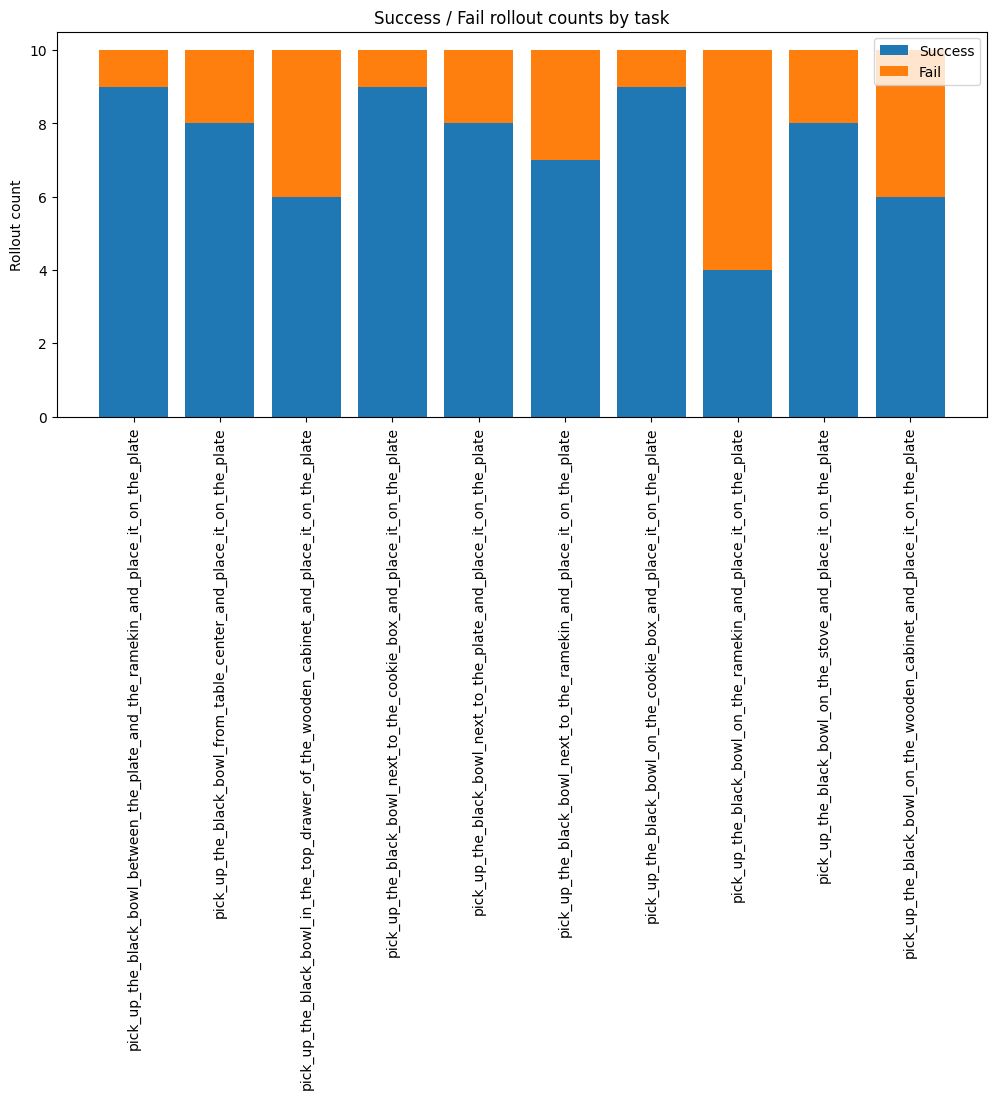

In [255]:
plt.figure(figsize=(12, 5))
x = np.arange(len(task_count_df))
plt.bar(x, task_count_df["success_count"], label="Success")
plt.bar(x, task_count_df["fail_count"], bottom=task_count_df["success_count"], label="Fail")
plt.xticks(x, task_count_df["task_name"], rotation=90)
plt.ylabel("Rollout count")
plt.title("Success / Fail rollout counts by task")
plt.legend()
plt.tight_layout()
plt.show()

In [256]:
# =========================================================
# 4. Task horizon (fixed: success_mean)
# =========================================================
def build_task_horizon_df(rollout_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for task_name, sub in rollout_df.groupby("task_name"):
        success_sub = sub[sub["success"] == 1]
        fail_sub = sub[sub["success"] == 0]

        success_len_mean = success_sub["traj_len"].mean() if len(success_sub) > 0 else np.nan
        success_len_median = success_sub["traj_len"].median() if len(success_sub) > 0 else np.nan
        all_len_mean = sub["traj_len"].mean()
        all_len_median = sub["traj_len"].median()

        is_valid_task = (
            (len(success_sub) >= MIN_SUCCESS_PER_TASK) and
            (len(fail_sub) >= MIN_FAIL_PER_TASK) and
            pd.notnull(success_len_mean)
        )

        cutoff_len = int(round(success_len_mean)) if pd.notnull(success_len_mean) else -1

        rows.append({
            "task_name": task_name,
            "n_success": len(success_sub),
            "n_fail": len(fail_sub),
            "success_len_mean": success_len_mean,
            "success_len_median": success_len_median,
            "all_len_mean": all_len_mean,
            "all_len_median": all_len_median,
            "cutoff_len": cutoff_len,
            "is_valid_task": is_valid_task,
        })

    return pd.DataFrame(rows)


task_horizon_df = build_task_horizon_df(rollout_df)
valid_tasks = task_horizon_df[task_horizon_df["is_valid_task"]]["task_name"].tolist()

print(f"# valid tasks: {len(valid_tasks)}")
display(task_horizon_df.sort_values(["is_valid_task", "n_success", "n_fail"], ascending=[False, False, False]))

# valid tasks: 7


,task_name,n_success,n_fail,success_len_mean,success_len_median,all_len_mean,all_len_median,cutoff_len,is_valid_task
1,pick_up_the_black_bowl_from_table_center_and_p...,8,2,109.750000,104.5,131.8,111.5,110,True
4,pick_up_the_black_bowl_next_to_the_plate_and_p...,8,2,104.500000,104.5,127.6,110.0,104,True
8,pick_up_the_black_bowl_on_the_stove_and_place_...,8,2,118.750000,119.5,139.0,123.0,119,True
5,pick_up_the_black_bowl_next_to_the_ramekin_and...,7,3,109.000000,103.0,142.3,118.0,109,True
2,pick_up_the_black_bowl_in_the_top_drawer_of_th...,6,4,135.833333,136.5,169.5,149.0,136,True
9,pick_up_the_black_bowl_on_the_wooden_cabinet_a...,6,4,128.333333,123.0,165.0,147.5,128,True
7,pick_up_the_black_bowl_on_the_ramekin_and_plac...,4,6,90.750000,90.0,168.3,220.0,91,True
0,pick_up_the_black_bowl_between_the_plate_and_t...,9,1,86.333333,87.0,99.7,87.0,86,False
3,pick_up_the_black_bowl_next_to_the_cookie_box_...,9,1,107.444444,102.0,118.7,104.0,107,False
6,pick_up_the_black_bowl_on_the_cookie_box_and_p...,9,1,90.444444,92.0,103.4,92.0,90,False


/tmp/ipykernel_2018960/2612151352.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


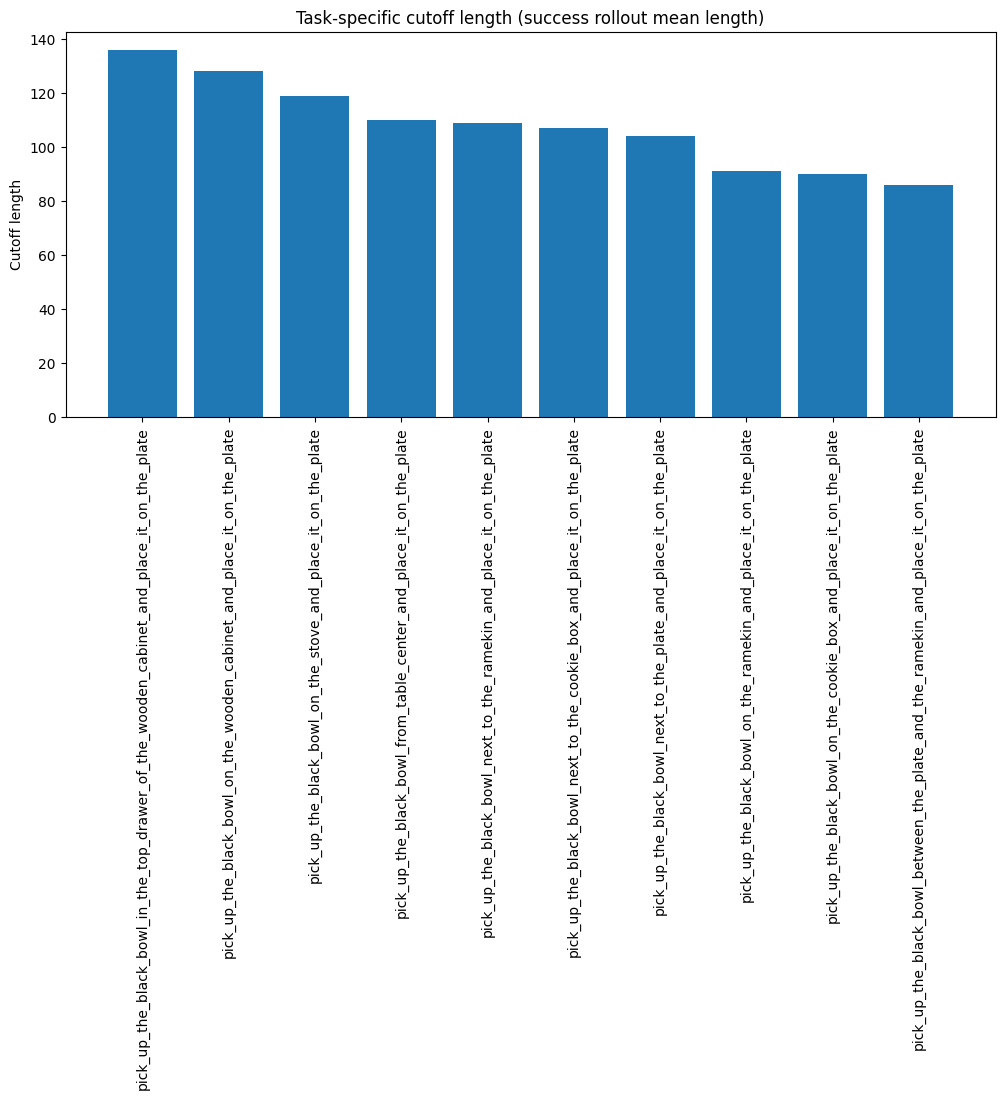

In [257]:
plot_df = task_horizon_df.sort_values("cutoff_len", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 5))
x = np.arange(len(plot_df))
plt.bar(x, plot_df["cutoff_len"])
plt.xticks(x, plot_df["task_name"], rotation=90)
plt.ylabel("Cutoff length")
plt.title("Task-specific cutoff length (success rollout mean length)")
plt.tight_layout()
plt.show()

In [258]:
# =========================================================
# 5. Base metric computation
# =========================================================
def compute_base_metric_series(logits: torch.Tensor) -> Dict[str, np.ndarray]:
    """
    logits: [T, 7, V]
    returns:
        dict of base metrics, each shape [T]
    """
    probs = torch.softmax(logits, dim=-1)  # [T, 7, V]

    entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=-1)  # [T, 7]
    max_prob = probs.max(dim=-1).values                        # [T, 7]

    top2 = torch.topk(probs, k=2, dim=-1).values               # [T, 7, 2]
    margin = top2[..., 0] - top2[..., 1]                       # [T, 7]

    top3_mass = torch.topk(probs, k=3, dim=-1).values.sum(dim=-1)  # [T, 7]
    top5_mass = torch.topk(probs, k=5, dim=-1).values.sum(dim=-1)  # [T, 7]

    vr = 1.0 - max_prob  # [T, 7]

    V = probs.shape[-1]
    idx = torch.arange(V, dtype=probs.dtype).view(1, 1, -1)    # [1, 1, V]
    argmax_idx = probs.argmax(dim=-1, keepdim=True).to(probs.dtype)  # [T, 7, 1]
    exp_dist = (torch.abs(idx - argmax_idx) * probs).sum(dim=-1)     # [T, 7]

    metric_map = {
        "confidence": max_prob.mean(dim=1).cpu().numpy(),
        "entropy": entropy.mean(dim=1).cpu().numpy(),
        "margin": margin.mean(dim=1).cpu().numpy(),
        "vr": vr.mean(dim=1).cpu().numpy(),
        "top3_mass": top3_mass.mean(dim=1).cpu().numpy(),
        "top5_mass": top5_mass.mean(dim=1).cpu().numpy(),
        "exp_dist": exp_dist.mean(dim=1).cpu().numpy(),
    }

    return metric_map

In [259]:
# =========================================================
# 6. Build metric cache
# =========================================================
def build_metric_cache(
    rollouts: List[RolloutRecord],
    valid_tasks: List[str],
) -> Dict[str, Dict[str, Any]]:
    cache = {}

    for r in rollouts:
        if r.task_name not in valid_tasks:
            continue

        cache[r.rollout_id] = {
            "task_name": r.task_name,
            "success": r.success,
            "trial_id": r.trial_id,
            "pt_name": r.pt_name,
            "step_ids": r.step_ids.copy(),
            "traj_len": r.traj_len,
            "base_metrics": compute_base_metric_series(r.logits),
        }

    return cache


metric_cache = build_metric_cache(rollouts, valid_tasks)

print(f"# cached rollouts: {len(metric_cache)}")
example_key = list(metric_cache.keys())[0]
print("Example rollout_id:", example_key)
print("Available base metrics:", list(metric_cache[example_key]["base_metrics"].keys()))

# cached rollouts: 70
Example rollout_id: 1_0
Available base metrics: ['confidence', 'entropy', 'margin', 'vr', 'top3_mass', 'top5_mass', 'exp_dist']


In [260]:
# =========================================================
# 7. Horizon truncation helpers
# =========================================================
task_cutoff_map = {
    row["task_name"]: int(row["cutoff_len"])
    for _, row in task_horizon_df.iterrows()
    if row["is_valid_task"]
}


def get_effective_horizon(task_name: str, rollout_len: int) -> int:
    """
    Task-specific cutoff = mean(success rollout length), but
    never exceed the actual rollout length.
    """
    cutoff_len = task_cutoff_map[task_name]
    return min(rollout_len, cutoff_len)


def truncate_to_effective_horizon(
    step_ids: np.ndarray,
    series: np.ndarray,
    task_name: str,
) -> Dict[str, np.ndarray]:
    effective_len = get_effective_horizon(task_name, len(series))

    return {
        "step_ids": step_ids[:effective_len],
        "series": series[:effective_len],
        "effective_len": effective_len,
    }

In [276]:
# =========================================================
# 8. Trigger score definition
# =========================================================
def rolling_mean_np(x: np.ndarray, window: int) -> np.ndarray:
    return pd.Series(x).rolling(window=window, min_periods=1).mean().to_numpy()


def diff_np(x: np.ndarray) -> np.ndarray:
    return np.diff(x, prepend=x[0])


# def compute_trigger_score(
#     base_metric_series: np.ndarray,
#     score_window: int,
# ) -> np.ndarray:
#     """
#     Fixed trigger score definition:
#         trigger_score = abs(diff(rolling_mean(base_metric, score_window)))
#     """
#     smooth = rolling_mean_np(base_metric_series, score_window)
#     score = np.abs(diff_np(smooth))
#     return score

# def compute_trigger_score(base_metric_series, score_window, metric_name):
#     smooth = rolling_mean_np(base_metric_series, score_window)
#     d = diff_np(smooth)

#     if metric_name in ["confidence", "margin", "top3_mass", "top5_mass"]:
#         score = np.maximum(0, -d)   # 떨어질 때만 bad
#     else:
#         score = np.maximum(0, d)    # 올라갈 때만 bad

#     score = (score - score.mean()) / (score.std() + 1e-6)
#     score = np.maximum(score, 0)

#     return score

def normalize01(x):
    x = np.asarray(x, dtype=float)
    if np.allclose(x.max(), x.min()):
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

def compute_trigger_score(base_metric_series, score_window, metric_name):
    smooth = rolling_mean_np(base_metric_series, score_window)
    d = diff_np(smooth)

    if metric_name in ["confidence", "margin", "top3_mass", "top5_mass"]:
        bad_level = normalize01(-smooth)      # 낮을수록 bad
        bad_change = normalize01(np.maximum(0, -d))
    else:
        bad_level = normalize01(smooth)       # 높을수록 bad
        bad_change = normalize01(np.maximum(0, d))

    score = 1.0 * bad_level + 0.0 * bad_change
    return score

In [277]:
# =========================================================
# 9. Trigger extraction
# =========================================================
def extract_trigger_events(
    step_ids: np.ndarray,
    trigger_score: np.ndarray,
    score_threshold: float,
    min_gap: int,
) -> Dict[str, Any]:
    trigger_mask = trigger_score > score_threshold
    trigger_steps = np.asarray(step_ids)[trigger_mask]

    if len(trigger_steps) == 0:
        return {
            "num_trigger_steps": 0,
            "num_trigger_events": 0,
            "trigger_ratio": 0.0,
            "event_steps": np.array([], dtype=int),
            "trigger_mask": trigger_mask,
        }

    merged_events = [int(trigger_steps[0])]
    last_kept = int(trigger_steps[0])

    for t in trigger_steps[1:]:
        t = int(t)
        if (t - last_kept) > min_gap:
            merged_events.append(t)
            last_kept = t

    return {
        "num_trigger_steps": int(trigger_mask.sum()),
        "num_trigger_events": int(len(merged_events)),
        "trigger_ratio": float(trigger_mask.mean()),
        "event_steps": np.asarray(merged_events, dtype=int),
        "trigger_mask": trigger_mask,
    }

In [278]:
# =========================================================
# 10. Evaluate one setting
# =========================================================
def evaluate_single_setting(
    base_metric: str,
    score_window: int,
    score_threshold: float,
    min_gap: int = MIN_GAP,
) -> pd.DataFrame:
    rows = []

    for rollout_id, item in metric_cache.items():
        task_name = item["task_name"]

        base_series_full = item["base_metrics"][base_metric]
        truncated = truncate_to_effective_horizon(
            step_ids=item["step_ids"],
            series=base_series_full,
            task_name=task_name,
        )

        step_ids = truncated["step_ids"]
        base_series = truncated["series"]
        effective_len = truncated["effective_len"]

        trigger_score = compute_trigger_score(
            base_metric_series=base_series,
            score_window=score_window,
            metric_name=base_metric,
        )

        trigger_out = extract_trigger_events(
            step_ids=step_ids,
            trigger_score=trigger_score,
            score_threshold=score_threshold,
            min_gap=min_gap,
        )

        rows.append({
            "rollout_id": rollout_id,
            "task_name": task_name,
            "success": item["success"],
            "trial_id": item["trial_id"],
            "pt_name": item["pt_name"],
            "base_metric": base_metric,
            "score_window": score_window,
            "score_threshold": float(score_threshold),
            "effective_len": int(effective_len),
            **trigger_out,
        })

    return pd.DataFrame(rows)

In [279]:
def summarize_single_setting(eval_df: pd.DataFrame) -> pd.DataFrame:
    success_df = eval_df[eval_df["success"] == 1]
    fail_df = eval_df[eval_df["success"] == 0]

    if len(success_df) == 0 or len(fail_df) == 0:
        return pd.DataFrame()

    eps = 1e-8
    feature = "num_trigger_events"

    svals = success_df[feature].values
    fvals = fail_df[feature].values

    s_mean = float(np.mean(svals))
    f_mean = float(np.mean(fvals))

    t_stat, p_value = stats.ttest_ind(svals, fvals, equal_var=False)

    try:
        auc_raw = roc_auc_score(eval_df["success"], eval_df[feature])
    except Exception:
        auc_raw = np.nan

    return pd.DataFrame([{
        "base_metric": eval_df["base_metric"].iloc[0],
        "score_window": int(eval_df["score_window"].iloc[0]),
        "score_threshold": float(eval_df["score_threshold"].iloc[0]),

        "n_success": len(success_df),
        "n_fail": len(fail_df),

        "success_mean": s_mean,
        "fail_mean": f_mean,
        "gap_fail_minus_success": float(f_mean - s_mean),
        "relative_gap_events": float((f_mean - s_mean)), #/ (s_mean + eps)),

        "t_stat": float(t_stat),
        "p_value": float(p_value),
        "roc_auc_raw": float(auc_raw) if pd.notnull(auc_raw) else np.nan,
        "roc_auc_fail_higher_better": (
            float(max(auc_raw, 1 - auc_raw)) if pd.notnull(auc_raw) else np.nan
        ),
    }])

In [280]:
def build_task_level_summary(eval_df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        eval_df.groupby(["task_name", "success"], as_index=False)
        .agg(
            num_rollouts=("rollout_id", "nunique"),
            mean_trigger_events=("num_trigger_events", "mean"),
        )
    )

    rows = []
    eps = 1e-8

    for task_name in sorted(grouped["task_name"].unique()):
        sub = grouped[grouped["task_name"] == task_name]

        s = sub[sub["success"] == 1]
        f = sub[sub["success"] == 0]

        if len(s) == 0 or len(f) == 0:
            continue

        s = s.iloc[0]
        f = f.iloc[0]

        s_events = float(s["mean_trigger_events"])
        f_events = float(f["mean_trigger_events"])

        rows.append({
            "task_name": task_name,
            "success_rollouts": int(s["num_rollouts"]),
            "fail_rollouts": int(f["num_rollouts"]),
            "success_mean_events": s_events,
            "fail_mean_events": f_events,
            "gap_events_fail_minus_success": float(f_events - s_events),
            "relative_gap_events": float(
                (f_events - s_events)# / (s_events + eps)
            ),
            "fail_gt_success_events": bool(f_events > s_events),
        })

    return pd.DataFrame(rows)

In [281]:
all_eval_dfs = []
all_summary_dfs = []
all_task_consistency_rows = []

for base_metric in BASE_METRICS:
    for score_window in SCORE_WINDOWS:
        for score_threshold in SCORE_THRESHOLDS[base_metric]:
            eval_df = evaluate_single_setting(
                base_metric=base_metric,
                score_window=score_window,
                score_threshold=score_threshold,
                min_gap=MIN_GAP,
            )

            summary_df = summarize_single_setting(eval_df)
            task_level_df = build_task_level_summary(eval_df)

            all_eval_dfs.append(eval_df)
            all_summary_dfs.append(summary_df)

            if len(task_level_df) > 0:
                all_task_consistency_rows.append({
                    "base_metric": base_metric,
                    "score_window": score_window,
                    "score_threshold": float(score_threshold),
                    "task_count": int(len(task_level_df)),
                    "event_consistency_rate": float(
                        task_level_df["fail_gt_success_events"].mean()
                    ),
                })

full_eval_df = pd.concat(all_eval_dfs, ignore_index=True)
full_summary_df = pd.concat(all_summary_dfs, ignore_index=True)
full_task_consistency_df = pd.DataFrame(all_task_consistency_rows)

print("full_eval_df:", full_eval_df.shape)
print("full_summary_df:", full_summary_df.shape)
print("full_task_consistency_df:", full_task_consistency_df.shape)



full_eval_df: (68600, 14)
full_summary_df: (980, 13)
full_task_consistency_df: (980, 5)


In [282]:
rank_df = full_summary_df.merge(
    full_task_consistency_df,
    on=["base_metric", "score_window", "score_threshold"],
    how="left",
)

rank_df["ranking_score"] = (
    1.0 * rank_df["roc_auc_fail_higher_better"]
    # + 1.0 * rank_df["relative_gap_events"]
    # + 1.0 * rank_df["event_consistency_rate"]
)

rank_df = rank_df.sort_values("ranking_score", ascending=False).reset_index(drop=True)

print("=== Top settings ===")
display(rank_df.head(100))

=== Top settings ===


,base_metric,score_window,score_threshold,n_success,n_fail,success_mean,fail_mean,gap_fail_minus_success,relative_gap_events,t_stat,p_value,roc_auc_raw,roc_auc_fail_higher_better,task_count,event_consistency_rate,ranking_score
0,top5_mass,2,0.8,47,23,3.106383,2.086957,-1.019426,-1.019426,2.863111,0.006058,0.698890,0.698890,7,0.000000,0.698890
1,top5_mass,3,0.8,47,23,2.851064,2.000000,-0.851064,-0.851064,2.235281,0.029637,0.662812,0.662812,7,0.142857,0.662812
2,top5_mass,2,0.6,47,23,6.617021,5.130435,-1.486586,-1.486586,1.776524,0.083132,0.652174,0.652174,7,0.000000,0.652174
3,top5_mass,3,0.6,47,23,6.510638,5.043478,-1.467160,-1.467160,1.804798,0.077678,0.645698,0.645698,7,0.142857,0.645698
4,top3_mass,2,0.8,47,23,3.510638,2.652174,-0.858464,-0.858464,1.697775,0.096054,0.635060,0.635060,7,0.000000,0.635060
5,exp_dist,1,0.4,47,23,11.276596,13.347826,2.071230,2.071230,-1.973014,0.055394,0.364940,0.635060,7,0.857143,0.635060
6,exp_dist,2,0.6,47,23,5.340426,6.565217,1.224792,1.224792,-1.766723,0.085024,0.370953,0.629047,7,0.857143,0.629047
7,margin,7,0.8,47,23,5.361702,4.739130,-0.622572,-0.622572,0.769732,0.446333,0.615171,0.615171,7,0.142857,0.615171
8,margin,4,0.8,47,23,4.978723,4.217391,-0.761332,-0.761332,1.202642,0.236254,0.614709,0.614709,7,0.428571,0.614709
9,margin,5,0.8,47,23,5.085106,4.217391,-0.867715,-0.867715,1.495696,0.141090,0.610546,0.610546,7,0.285714,0.610546


In [283]:
# =========================================================
# 16. Select best setting
# =========================================================
best_row = rank_df.iloc[0]

best_setting = {
    "base_metric": best_row["base_metric"],
    "score_window": int(best_row["score_window"]),
    "score_threshold": float(best_row["score_threshold"]),
}

print("=== Best setting ===")
print(best_setting)

=== Best setting ===
{'base_metric': 'top5_mass', 'score_window': 2, 'score_threshold': 0.8}


In [284]:
# =========================================================
# 17. Re-evaluate best setting
# =========================================================
best_eval_df = evaluate_single_setting(
    base_metric=best_setting["base_metric"],
    score_window=best_setting["score_window"],
    score_threshold=best_setting["score_threshold"],
    min_gap=MIN_GAP,
)

best_summary_df = summarize_single_setting(best_eval_df)
best_task_level_df = build_task_level_summary(best_eval_df)

print("=== Best setting summary ===")
display(best_summary_df)

print("=== Best setting task-level summary ===")
display(best_task_level_df.sort_values("gap_events_fail_minus_success", ascending=False))

=== Best setting summary ===


,base_metric,score_window,score_threshold,n_success,n_fail,success_mean,fail_mean,gap_fail_minus_success,relative_gap_events,t_stat,p_value,roc_auc_raw,roc_auc_fail_higher_better
0,top5_mass,2,0.8,47,23,3.106383,2.086957,-1.019426,-1.019426,2.863111,0.006058,0.69889,0.69889


=== Best setting task-level summary ===


,task_name,success_rollouts,fail_rollouts,success_mean_events,fail_mean_events,gap_events_fail_minus_success,relative_gap_events,fail_gt_success_events
6,pick_up_the_black_bowl_on_the_wooden_cabinet_a...,6,4,3.000000,2.750000,-0.250000,-0.250000,False
1,pick_up_the_black_bowl_in_the_top_drawer_of_th...,6,4,3.833333,3.000000,-0.833333,-0.833333,False
4,pick_up_the_black_bowl_on_the_ramekin_and_plac...,4,6,3.000000,2.000000,-1.000000,-1.000000,False
2,pick_up_the_black_bowl_next_to_the_plate_and_p...,8,2,3.250000,2.000000,-1.250000,-1.250000,False
3,pick_up_the_black_bowl_next_to_the_ramekin_and...,7,3,2.714286,1.333333,-1.380952,-1.380952,False
0,pick_up_the_black_bowl_from_table_center_and_p...,8,2,2.625000,1.000000,-1.625000,-1.625000,False
5,pick_up_the_black_bowl_on_the_stove_and_place_...,8,2,3.375000,1.500000,-1.875000,-1.875000,False


/tmp/ipykernel_2018960/3805711742.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Success", "Fail"])


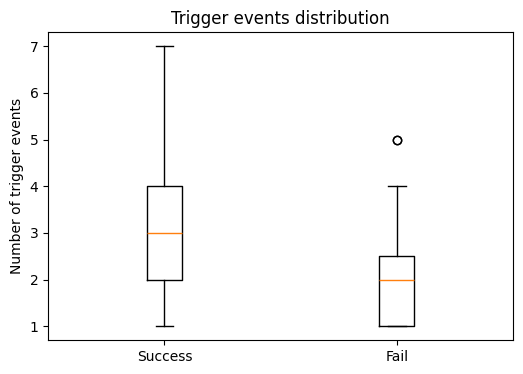

In [285]:
# =========================================================
# 18. Visualization: event distribution
# =========================================================
plt.figure(figsize=(6,4))

data = [
    best_eval_df[best_eval_df["success"] == 1]["num_trigger_events"],
    best_eval_df[best_eval_df["success"] == 0]["num_trigger_events"],
]

plt.boxplot(data, labels=["Success", "Fail"])
plt.ylabel("Number of trigger events")
plt.title("Trigger events distribution")
plt.show()

/tmp/ipykernel_2018960/1519422451.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


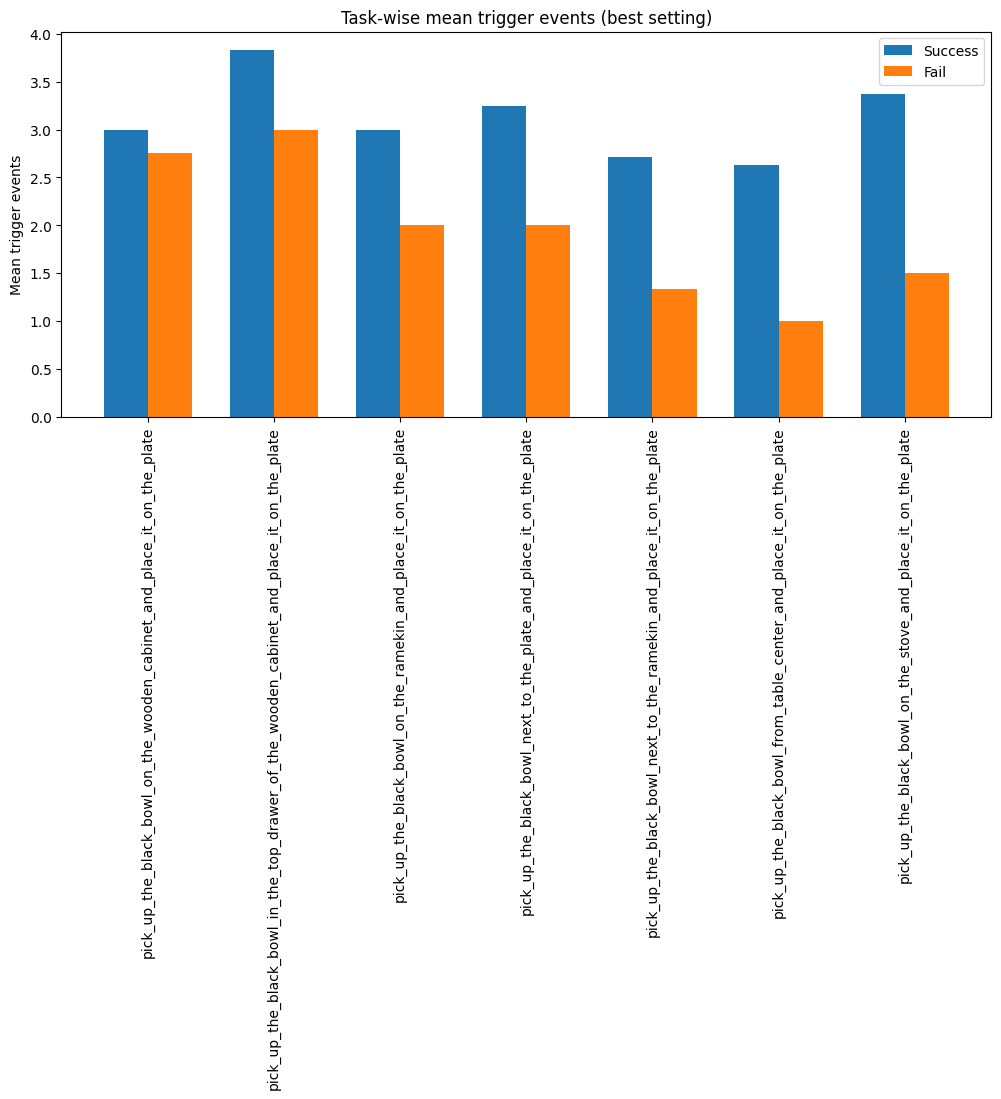

In [286]:
# =========================================================
# 19. Visualization: task-wise mean events
# =========================================================
plot_df = best_task_level_df.sort_values("gap_events_fail_minus_success", ascending=False).reset_index(drop=True)

plt.figure(figsize=(max(12, len(plot_df) * 0.6), 5))
x = np.arange(len(plot_df))
width = 0.35

plt.bar(x - width/2, plot_df["success_mean_events"], width, label="Success")
plt.bar(x + width/2, plot_df["fail_mean_events"], width, label="Fail")

plt.xticks(x, plot_df["task_name"], rotation=90)
plt.ylabel("Mean trigger events")
plt.title("Task-wise mean trigger events (best setting)")
plt.legend()
plt.tight_layout()
plt.show()

In [287]:
# =========================================================
# 20. Build success background for qualitative plots
# =========================================================
def build_success_trigger_score_background(
    base_metric: str,
    score_window: int,
) -> Dict[str, pd.DataFrame]:
    rows = []

    for rollout_id, item in metric_cache.items():
        if item["success"] != 1:
            continue

        task_name = item["task_name"]
        base_series_full = item["base_metrics"][base_metric]

        truncated = truncate_to_effective_horizon(
            step_ids=item["step_ids"],
            series=base_series_full,
            task_name=task_name,
        )

        step_ids = truncated["step_ids"]
        base_series = truncated["series"]

        trigger_score = compute_trigger_score(
            base_metric_series=base_series,
            score_window=score_window,
            metric_name=base_metric,
        )

        for i, step_id in enumerate(step_ids):
            rows.append({
                "task_name": task_name,
                "step_id": int(step_id),
                "trigger_score": float(trigger_score[i]),
            })

    df = pd.DataFrame(rows)

    background = {}
    for task_name, sub in df.groupby("task_name"):
        summary = (
            sub.groupby("step_id", as_index=False)
            .agg(
                mean_score=("trigger_score", "mean"),
                std_score=("trigger_score", "std"),
                n=("trigger_score", "size"),
            )
        )
        summary["std_score"] = summary["std_score"].fillna(0.0)
        background[task_name] = summary

    return background


best_background = build_success_trigger_score_background(
    base_metric=best_setting["base_metric"],
    score_window=best_setting["score_window"],
)

Selected fail examples:
['9_3', '5_5', '4_1', '4_2', '9_9']


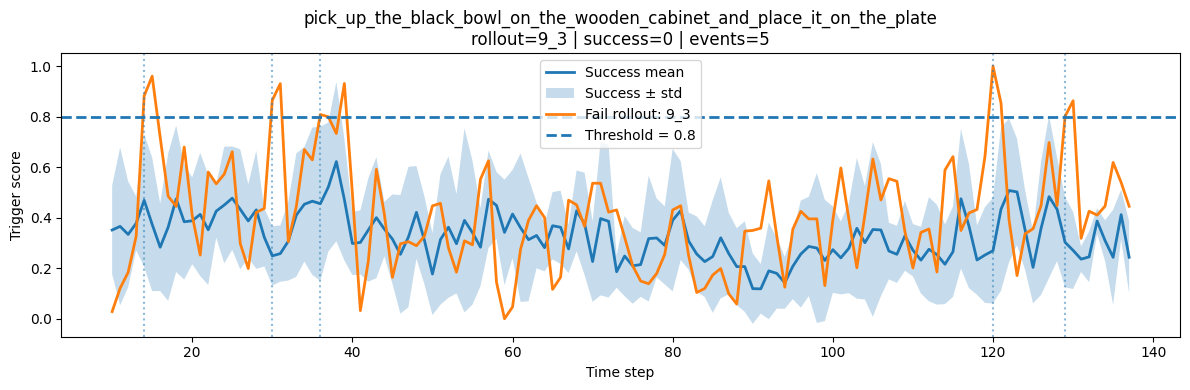

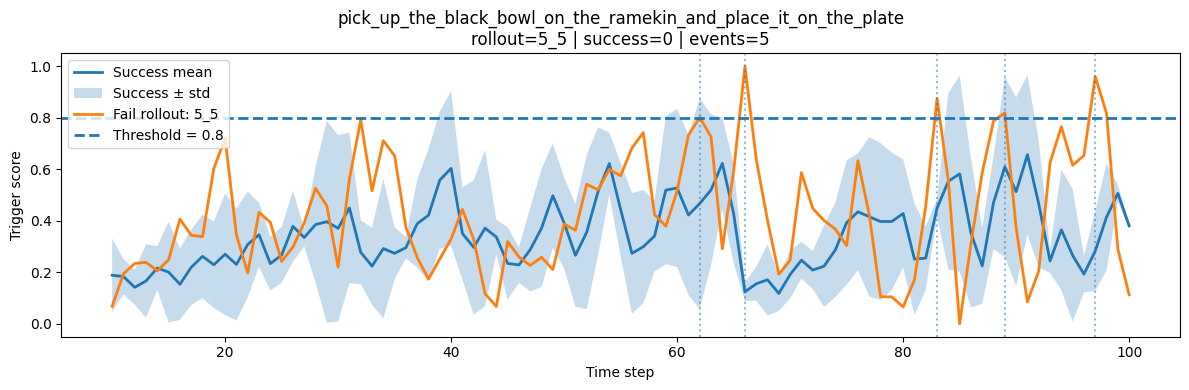

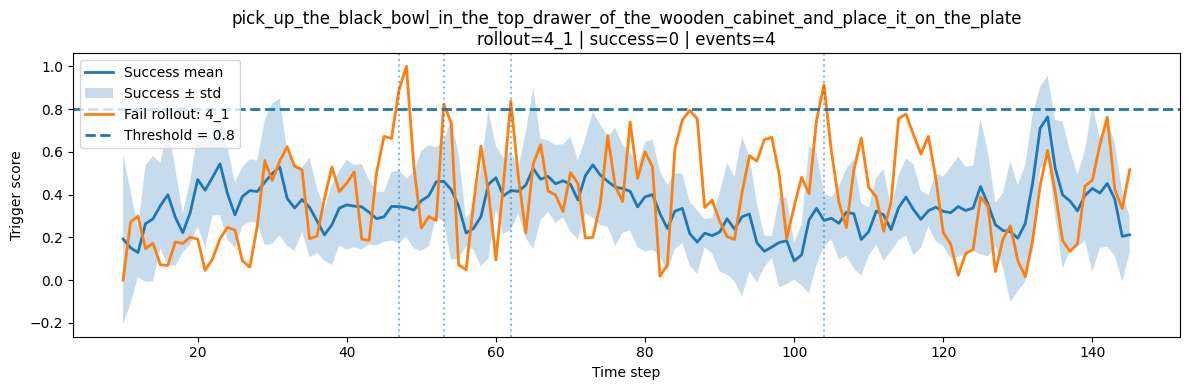

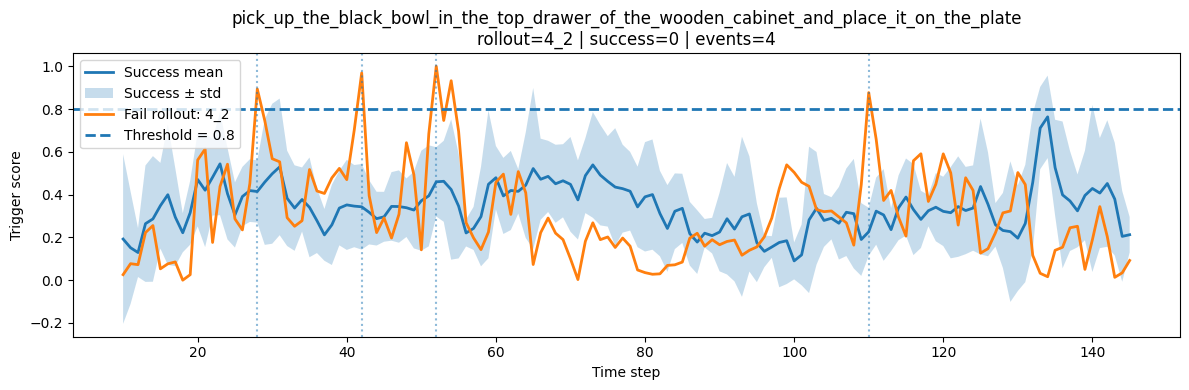

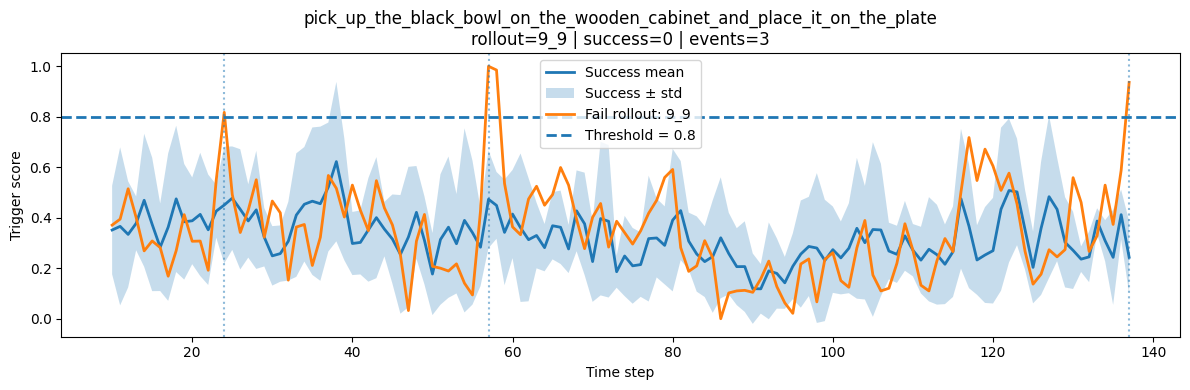

In [288]:
# =========================================================
# 21. Qualitative fail rollout overlay
# =========================================================
fail_examples = (
    best_eval_df[best_eval_df["success"] == 0]
    .sort_values("num_trigger_events", ascending=False)
    .head(5)["rollout_id"]
    .tolist()
)

print("Selected fail examples:")
print(fail_examples)

for rollout_id in fail_examples:
    item = metric_cache[rollout_id]
    task_name = item["task_name"]

    base_series_full = item["base_metrics"][best_setting["base_metric"]]
    truncated = truncate_to_effective_horizon(
        step_ids=item["step_ids"],
        series=base_series_full,
        task_name=task_name,
    )

    step_ids = truncated["step_ids"]
    base_series = truncated["series"]

    trigger_score = compute_trigger_score(
        base_metric_series=base_series,
        score_window=best_setting["score_window"],
        metric_name=best_setting["base_metric"],
    )

    trigger_out = extract_trigger_events(
        step_ids=step_ids,
        trigger_score=trigger_score,
        score_threshold=best_setting["score_threshold"],
        min_gap=MIN_GAP,
    )

    background_df = best_background[task_name]

    plt.figure(figsize=(12, 4))

    plt.plot(
        background_df["step_id"],
        background_df["mean_score"],
        label="Success mean",
        linewidth=2,
    )
    plt.fill_between(
        background_df["step_id"],
        background_df["mean_score"] - background_df["std_score"],
        background_df["mean_score"] + background_df["std_score"],
        alpha=0.25,
        label="Success ± std",
    )

    plt.plot(
        step_ids,
        trigger_score,
        linewidth=2,
        label=f"Fail rollout: {rollout_id}",
    )

    plt.axhline(
        best_setting["score_threshold"],
        linestyle="--",
        linewidth=2,
        label=f"Threshold = {best_setting['score_threshold']}",
    )

    for t in trigger_out["event_steps"]:
        plt.axvline(t, linestyle=":", alpha=0.5)

    plt.xlabel("Time step")
    plt.ylabel("Trigger score")
    plt.title(
        f"{task_name}\n"
        f"rollout={rollout_id} | success=0 | events={trigger_out['num_trigger_events']}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

In [289]:
# =========================================================
# 22. Heatmap for ranking landscape
# =========================================================
def draw_heatmap(ax, df, value_col, title, metric_order=None, fmt=".2f"):
    plot_df = df.copy()

    if metric_order is None:
        metric_order = sorted(plot_df["base_metric"].unique())

    plot_df["base_metric"] = pd.Categorical(
        plot_df["base_metric"],
        categories=metric_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values(["base_metric", "score_threshold"])

    pivot = plot_df.pivot(
        index="base_metric",
        columns="score_threshold",
        values=value_col,
    )

    pivot = pivot.loc[[m for m in metric_order if m in pivot.index]]

    data = pivot.values
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{c:.3f}" for c in pivot.columns], rotation=0)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Score threshold")
    ax.set_ylabel("Base metric")
    ax.set_title(title)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if pd.notnull(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

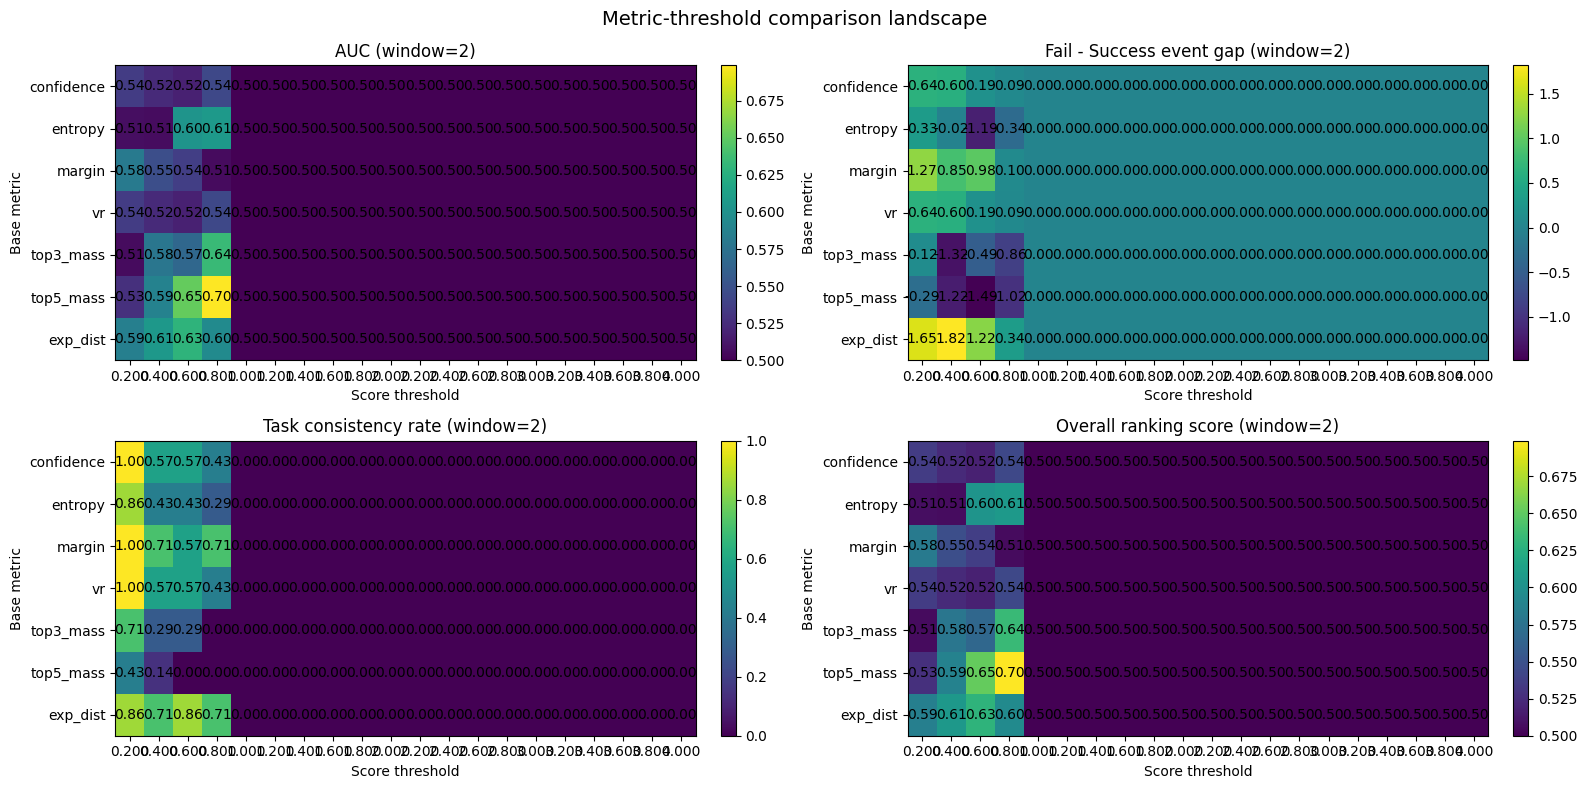

In [290]:
window_to_plot = best_setting["score_window"]
heatmap_df = rank_df[rank_df["score_window"] == window_to_plot].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

metric_order = ["confidence", "entropy", "margin", "vr", "top3_mass", "top5_mass", "exp_dist"]

draw_heatmap(
    axes[0, 0],
    heatmap_df,
    value_col="roc_auc_fail_higher_better",
    title=f"AUC (window={window_to_plot})",
    metric_order=metric_order,
    fmt=".2f",
)

draw_heatmap(
    axes[0, 1],
    heatmap_df,
    value_col="gap_fail_minus_success",
    title=f"Fail - Success event gap (window={window_to_plot})",
    metric_order=metric_order,
    fmt=".2f",
)

draw_heatmap(
    axes[1, 0],
    heatmap_df,
    value_col="event_consistency_rate",
    title=f"Task consistency rate (window={window_to_plot})",
    metric_order=metric_order,
    fmt=".2f",
)

draw_heatmap(
    axes[1, 1],
    heatmap_df,
    value_col="ranking_score",
    title=f"Overall ranking score (window={window_to_plot})",
    metric_order=metric_order,
    fmt=".2f",
)

plt.suptitle("Metric-threshold comparison landscape", fontsize=14)
plt.tight_layout()
plt.show()